In [9]:
import pandas as pd
import numpy as np

# Chargement
df = pd.read_csv("../data/raw/reviews_all_beauty.csv")

print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nTypes de données :\n{df.dtypes}")


Dimensions : 701,528 lignes × 10 colonnes

Colonnes : ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

Types de données :
rating               float64
title                    str
text                     str
images                   str
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object


## Étape 1 — Nettoyage de base

### 1.1 Suppression des colonnes inutiles

Les colonnes `images`, `title`, `parent_asin` et `helpful_vote` ne seront pas utilisées dans le système de recommandation collaboratif :
- `images` : liens vers des photos, aucune valeur pour la reco
- `title` : doublon partiel du `text`, trop court pour le NLP
- `parent_asin` : regroupement de variantes produit — on travaille au niveau `asin`
- `helpful_vote` : trop de valeurs à 0, signal trop faible

In [10]:
colonnes_a_garder = ['user_id', 'asin', 'rating', 'text', 'timestamp', 'verified_purchase']
df = df[colonnes_a_garder].copy()

print(f"Colonnes conservées : {df.columns.tolist()}")
print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

Colonnes conservées : ['user_id', 'asin', 'rating', 'text', 'timestamp', 'verified_purchase']
Dimensions : 701,528 lignes × 6 colonnes


### 1.2 Suppression des doublons

Un même utilisateur ne devrait avoir qu'un seul avis par produit. Si ce n'est pas le cas, on garde le plus récent (timestamp le plus élevé) car il reflète mieux l'opinion actuelle de l'utilisateur.

In [11]:
avant = len(df)

# Tri par timestamp décroissant puis suppression des doublons user+produit
df = df.sort_values('timestamp', ascending=False)
df = df.drop_duplicates(subset=['user_id', 'asin'], keep='first')

apres = len(df)
print(f"Doublons supprimés : {avant - apres:,}")
print(f"Dimensions après   : {apres:,} lignes")

Doublons supprimés : 7,276
Dimensions après   : 694,252 lignes


### 1.3 Suppression des valeurs manquantes

`rating` est obligatoire — c'est le signal central du modèle. `text` manquant (0.03%) est acceptable : on supprime ces lignes car elles seront inutilisables pour la partie NLP/contenu.

In [12]:
avant = len(df)

df = df.dropna(subset=['rating', 'text'])

apres = len(df)
print(f"Lignes supprimées (valeurs manquantes) : {avant - apres:,}")
print(f"Dimensions après : {apres:,} lignes")
print(f"\nValeurs manquantes restantes :\n{df.isnull().sum()}")

Lignes supprimées (valeurs manquantes) : 211
Dimensions après : 694,041 lignes

Valeurs manquantes restantes :
user_id              0
asin                 0
rating               0
text                 0
timestamp            0
verified_purchase    0
dtype: int64


### 1.4 Conversion du timestamp

On convertit le timestamp (en millisecondes) en datetime lisible et on extrait l'année pour pouvoir filtrer plus tard.

In [13]:
df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
df['year'] = df['date'].dt.year
df = df.drop(columns=['timestamp'])

print("Période couverte :")
print(f"  Du  : {df['date'].min().strftime('%B %Y')}")
print(f"  Au  : {df['date'].max().strftime('%B %Y')}")
print(f"\nAperçu :\n")
df.head(3)

Période couverte :
  Du  : November 2000
  Au  : September 2023

Aperçu :



,user_id,asin,rating,text,verified_purchase,date,year
701439,AHURE3VT2MLCTARMYI7JA7KKDYAA,B0CBBZ9MJ4,1.0,The wig is not real. It’s a scam. I am so disa...,True,2023-09-09 00:39:36.666,2023
700817,AFAKRS26G7C3J2ONZGZEXXXS3UEQ,B09QP39NW4,5.0,"Last forever, cheap, supports troops",True,2023-09-08 19:42:19.837,2023
700571,AHHH7JVM5PBIMJQXKGYNUJBOUTDA,B00EEN2HCS,5.0,Very easy to use. The results are exactly as d...,True,2023-09-08 14:05:11.504,2023


### 1.5 Bilan du nettoyage

In [14]:
print("=" * 40)
print("       BILAN ÉTAPE 1 — NETTOYAGE")
print("=" * 40)
print(f"Lignes initiales  : 701,528")
print(f"Lignes finales    : {len(df):,}")
print(f"Lignes supprimées : {701528 - len(df):,} ({(701528 - len(df))/701528*100:.2f}%)")
print(f"\nColonnes finales  : {df.columns.tolist()}")

import os
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/reviews_clean.csv", index=False)
print("\nFichier sauvegardé : data/processed/reviews_clean.csv")

       BILAN ÉTAPE 1 — NETTOYAGE
Lignes initiales  : 701,528
Lignes finales    : 694,041
Lignes supprimées : 7,487 (1.07%)

Colonnes finales  : ['user_id', 'asin', 'rating', 'text', 'verified_purchase', 'date', 'year']

Fichier sauvegardé : data/processed/reviews_clean.csv


## Étape 2 — Filtrage de la matrice

### 2.1 Choix des seuils

On applique un filtrage itératif : supprimer les utilisateurs peu actifs crée de nouveaux produits orphelins, et vice versa. On répète donc le filtrage jusqu'à stabilisation.

- **Utilisateurs ≥ 3 avis** : en dessous, impossible d'identifier des préférences
- **Produits ≥ 5 avis** : en dessous, la note moyenne n'est pas représentative

In [15]:
MIN_AVIS_USER    = 3
MIN_AVIS_PRODUIT = 5

df_filtre = df.copy()
iteration = 0

while True:
    iteration += 1
    avant = len(df_filtre)

    # Filtrage utilisateurs
    users_ok = df_filtre['user_id'].value_counts()
    users_ok = users_ok[users_ok >= MIN_AVIS_USER].index
    df_filtre = df_filtre[df_filtre['user_id'].isin(users_ok)]

    # Filtrage produits
    produits_ok = df_filtre['asin'].value_counts()
    produits_ok = produits_ok[produits_ok >= MIN_AVIS_PRODUIT].index
    df_filtre = df_filtre[df_filtre['asin'].isin(produits_ok)]

    apres = len(df_filtre)
    print(f"Itération {iteration} : {avant:,} → {apres:,} lignes (-{avant - apres:,})")

    # Arrêt quand plus rien ne change
    if avant == apres:
        break

print(f"\nFiltrage stabilisé en {iteration} itération(s)")

Itération 1 : 694,041 → 11,474 lignes (-682,567)
Itération 2 : 11,474 → 6,496 lignes (-4,978)
Itération 3 : 6,496 → 5,959 lignes (-537)
Itération 4 : 5,959 → 5,744 lignes (-215)
Itération 5 : 5,744 → 5,653 lignes (-91)
Itération 6 : 5,653 → 5,631 lignes (-22)
Itération 7 : 5,631 → 5,617 lignes (-14)
Itération 8 : 5,617 → 5,609 lignes (-8)
Itération 9 : 5,609 → 5,609 lignes (-0)

Filtrage stabilisé en 9 itération(s)


### 2.2 Bilan du filtrage

In [16]:
n_u = df_filtre['user_id'].nunique()
n_i = df_filtre['asin'].nunique()
n_r = len(df_filtre)
sparsite = (1 - n_r / (n_u * n_i)) * 100

print("=" * 40)
print("     BILAN ÉTAPE 2 — FILTRAGE")
print("=" * 40)
print(f"Utilisateurs : {n_u:,}  (était {df['user_id'].nunique():,})")
print(f"Produits     : {n_i:,} (était {df['asin'].nunique():,})")
print(f"Avis         : {n_r:,}  (était {len(df):,})")
print(f"Sparsité     : {sparsite:.4f}%")
print(f"\nDonnées conservées : {n_r/len(df)*100:.1f}%")

df_filtre.to_csv("../data/processed/reviews_filtered.csv", index=False)
print("\nFichier sauvegardé : data/processed/reviews_filtered.csv")

     BILAN ÉTAPE 2 — FILTRAGE
Utilisateurs : 806  (était 631,809)
Produits     : 730 (était 115,697)
Avis         : 5,609  (était 694,041)
Sparsité     : 99.0467%

Données conservées : 0.8%

Fichier sauvegardé : data/processed/reviews_filtered.csv


## Étape 3 — Normalisation des notes

### Pourquoi normaliser ?

Chaque utilisateur a son propre style de notation :
- L'utilisateur A donne toujours 4-5 même quand il est peu satisfait
- L'utilisateur B donne 3 pour un produit qu'il trouve bon

Sans normalisation, le modèle va confondre ces biais personnels avec de vraies préférences. On centre les notes de chaque utilisateur autour de **0** en soustrayant sa moyenne :

```
note_normalisée = note - moyenne_utilisateur
```

Résultat : une note positive = l'utilisateur aime **plus que d'habitude**, une note négative = il aime **moins que d'habitude**.

### 3.1 Calcul de la moyenne par utilisateur

In [17]:
# Moyenne de notation par utilisateur
moyenne_par_user = df_filtre.groupby('user_id')['rating'].mean().rename('rating_mean_user')

print("=== Distribution des moyennes par utilisateur ===")
print(moyenne_par_user.describe().round(2))

print(f"\nExemple — 5 utilisateurs :")
print(moyenne_par_user.head())

=== Distribution des moyennes par utilisateur ===
count    806.00
mean       4.33
std        0.55
min        2.33
25%        4.00
50%        4.40
75%        4.75
max        5.00
Name: rating_mean_user, dtype: float64

Exemple — 5 utilisateurs :
user_id
AE23ZBUF2YVBQPH2NN6F5XSA3QYQ    4.153846
AE2IGWDKOWONDB3FQFX3STYGWCNQ    4.285714
AE2O2C43KTYO4LXXGZWJZLE67GBQ    3.428571
AE2WYNQPBMS67OHFWV63NI4MSJEA    4.400000
AE3335XF4PMHSXKTW5B7N7EALG3Q    3.166667
Name: rating_mean_user, dtype: float64


### 3.2 Application de la normalisation

In [18]:
df_norm = df_filtre.merge(moyenne_par_user, on='user_id')

# Note centrée = note brute - moyenne de l'utilisateur
df_norm['rating_normalized'] = df_norm['rating'] - df_norm['rating_mean_user']

print("=== Vérification ===")
print(f"Plage note brute       : [{df_norm['rating'].min():.1f}, {df_norm['rating'].max():.1f}]")
print(f"Plage note normalisée  : [{df_norm['rating_normalized'].min():.2f}, {df_norm['rating_normalized'].max():.2f}]")
print(f"Moyenne note normalisée: {df_norm['rating_normalized'].mean():.6f}  (doit être ≈ 0)")

print("\nAperçu :")
df_norm[['user_id', 'asin', 'rating', 'rating_mean_user', 'rating_normalized']].head(5)

=== Vérification ===
Plage note brute       : [1.0, 5.0]
Plage note normalisée  : [-3.53, 2.00]
Moyenne note normalisée: 0.000000  (doit être ≈ 0)

Aperçu :


,user_id,asin,rating,rating_mean_user,rating_normalized
0,AGS4KJHF5LOOWT2A5TJJFMB24VOA,B09X23VTSQ,4.0,3.888889,0.111111
1,AGRX7ZI7LBRKIZEEVAJFE56T2UMA,B087FTZSZH,4.0,4.666667,-0.666667
2,AGYQ2VYAIX2UQHT252VXWWTUP75A,B0BNJ2KVTP,5.0,5.000000,0.000000
3,AGRX7ZI7LBRKIZEEVAJFE56T2UMA,B0B2DN2MHK,5.0,4.666667,0.333333
4,AGYGB42MVBQ4X2XNEX45VHJD7GOA,B0BPC2QG37,4.0,4.666667,-0.666667


la normalisation est correcte. En centrant chaque utilisateur sur sa propre moyenne, on annule tous les biais individuels de notation.

### 3.3 Visualisation — avant / après normalisation

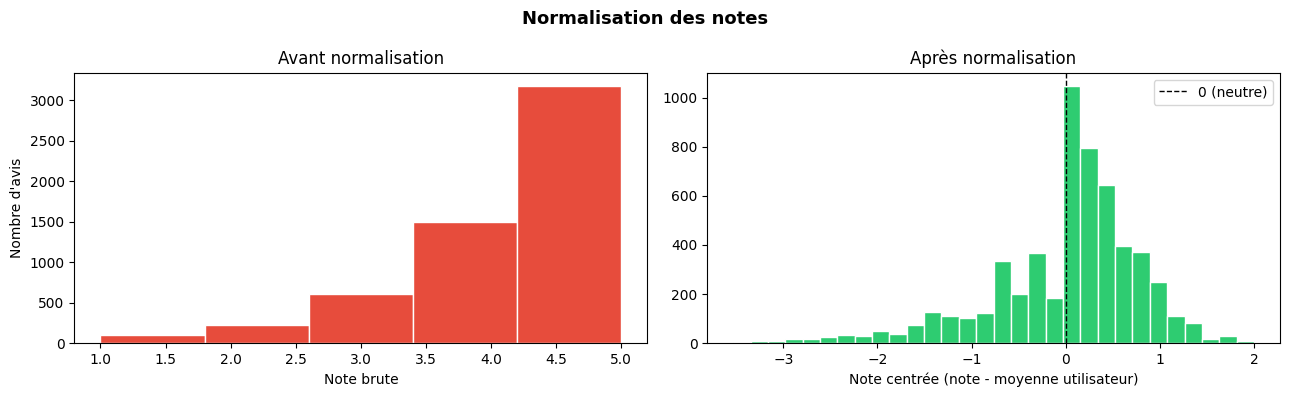

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Normalisation des notes", fontsize=13, fontweight='bold')

# Avant
axes[0].hist(df_norm['rating'], bins=5, color='#e74c3c', edgecolor='white')
axes[0].set_title("Avant normalisation")
axes[0].set_xlabel("Note brute")
axes[0].set_ylabel("Nombre d'avis")

# Après
axes[1].hist(df_norm['rating_normalized'], bins=30, color='#2ecc71', edgecolor='white')
axes[1].set_title("Après normalisation")
axes[1].set_xlabel("Note centrée (note - moyenne utilisateur)")
axes[1].axvline(0, color='black', linestyle='--', linewidth=1, label='0 (neutre)')
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/normalisation_notes.png", dpi=150, bbox_inches='tight')
plt.show()

83% des avis sont dans la plage [-1, +1] — le signal est concentré et exploitable. Les valeurs extrêmes (-3.53) correspondent à l'utilisateur critique qui donne un 1 alors que sa moyenne est à 4.5.

### 3.4 Sauvegarde

In [20]:
df_norm.to_csv("../data/processed/reviews_normalized.csv", index=False)

print("=" * 40)
print("   BILAN ÉTAPE 3 — NORMALISATION")
print("=" * 40)
print(f"Lignes             : {len(df_norm):,}")
print(f"Colonnes           : {df_norm.columns.tolist()}")
print("\nFichier sauvegardé : data/processed/reviews_normalized.csv")

   BILAN ÉTAPE 3 — NORMALISATION
Lignes             : 5,609
Colonnes           : ['user_id', 'asin', 'rating', 'text', 'verified_purchase', 'date', 'year', 'rating_mean_user', 'rating_normalized']

Fichier sauvegardé : data/processed/reviews_normalized.csv


## Étape 4 — Encodage des identifiants

### Pourquoi encoder ?

Les modèles ML (KNN, SVD, réseaux de neurones) ne travaillent pas avec des chaînes de caractères comme `"AGKHLEW2SOWHNMFQIJGBECAF7INQ"` ou `"B00YQ6X8EO"`. Ils ont besoin d'**indices entiers** commençant à 0 pour :
- Indexer les lignes/colonnes de la matrice utilisateur-produit
- Alimenter les couches d'embedding des modèles

On crée deux mappings :
- `user_id` → entier de 0 à N_users-1
- `asin` → entier de 0 à N_items-1

### 4.1 Création des mappings user et produit

In [21]:
# Mapping user_id → index entier
users_uniques = sorted(df_norm['user_id'].unique())
user2idx = {user: idx for idx, user in enumerate(users_uniques)}
idx2user = {idx: user for user, idx in user2idx.items()}

# Mapping asin → index entier
items_uniques = sorted(df_norm['asin'].unique())
item2idx = {item: idx for idx, item in enumerate(items_uniques)}
idx2item = {idx: item for item, idx in item2idx.items()}

print(f"Nombre d'utilisateurs encodés : {len(user2idx):,}")
print(f"Nombre de produits encodés    : {len(item2idx):,}")

print("\nExemples de mapping utilisateur :")
for user, idx in list(user2idx.items())[:3]:
    print(f"  {user}  →  {idx}")

print("\nExemples de mapping produit :")
for item, idx in list(item2idx.items())[:3]:
    print(f"  {item}  →  {idx}")

Nombre d'utilisateurs encodés : 806
Nombre de produits encodés    : 730

Exemples de mapping utilisateur :
  AE23ZBUF2YVBQPH2NN6F5XSA3QYQ  →  0
  AE2IGWDKOWONDB3FQFX3STYGWCNQ  →  1
  AE2O2C43KTYO4LXXGZWJZLE67GBQ  →  2

Exemples de mapping produit :
  B005AL5H9S  →  0
  B009GPP546  →  1
  B00BETY3EU  →  2


### 4.2 Application des encodages au dataset

In [22]:
df_encoded = df_norm.copy()
df_encoded['user_idx'] = df_encoded['user_id'].map(user2idx)
df_encoded['item_idx'] = df_encoded['asin'].map(item2idx)

print("Vérification — aucune valeur manquante dans les index :")
print(f"  user_idx nuls : {df_encoded['user_idx'].isnull().sum()}")
print(f"  item_idx nuls : {df_encoded['item_idx'].isnull().sum()}")

print(f"\nPlage user_idx : [{df_encoded['user_idx'].min()}, {df_encoded['user_idx'].max()}]")
print(f"Plage item_idx : [{df_encoded['item_idx'].min()}, {df_encoded['item_idx'].max()}]")

print("\nAperçu :")
df_encoded[['user_id', 'user_idx', 'asin', 'item_idx', 'rating', 'rating_normalized']].head(4)

Vérification — aucune valeur manquante dans les index :
  user_idx nuls : 0
  item_idx nuls : 0

Plage user_idx : [0, 805]
Plage item_idx : [0, 729]

Aperçu :


,user_id,user_idx,asin,item_idx,rating,rating_normalized
0,AGS4KJHF5LOOWT2A5TJJFMB24VOA,566,B09X23VTSQ,664,4.0,0.111111
1,AGRX7ZI7LBRKIZEEVAJFE56T2UMA,564,B087FTZSZH,255,4.0,-0.666667
2,AGYQ2VYAIX2UQHT252VXWWTUP75A,603,B0BNJ2KVTP,727,5.0,0.000000
3,AGRX7ZI7LBRKIZEEVAJFE56T2UMA,564,B0B2DN2MHK,680,5.0,0.333333


### 4.3 Sauvegarde des mappings et du dataset encodé

In [23]:
import json

# Sauvegarde des mappings pour pouvoir retrouver les vrais IDs après prédiction
with open("../data/processed/user2idx.json", "w") as f:
    json.dump(user2idx, f)

with open("../data/processed/item2idx.json", "w") as f:
    json.dump(item2idx, f)

# Sauvegarde du dataset encodé
df_encoded.to_csv("../data/processed/reviews_encoded.csv", index=False)

print("=" * 40)
print("   BILAN ÉTAPE 4 — ENCODAGE")
print("=" * 40)
print(f"Colonnes finales : {df_encoded.columns.tolist()}")
print(f"\nFichiers sauvegardés :")
print("  data/processed/reviews_encoded.csv")
print("  data/processed/user2idx.json")
print("  data/processed/item2idx.json")

   BILAN ÉTAPE 4 — ENCODAGE
Colonnes finales : ['user_id', 'asin', 'rating', 'text', 'verified_purchase', 'date', 'year', 'rating_mean_user', 'rating_normalized', 'user_idx', 'item_idx']

Fichiers sauvegardés :
  data/processed/reviews_encoded.csv
  data/processed/user2idx.json
  data/processed/item2idx.json


## Étape 5 — Split train / test

### Pourquoi un split par utilisateur ?

Un split aléatoire classique (80/20 sur toutes les lignes) est incorrect pour la recommandation : le modèle pourrait apprendre sur des avis d'un utilisateur et être évalué sur d'autres avis du même utilisateur, ce qui **surestime** les performances.

La bonne approche est le **split temporel par utilisateur** :
- Pour chaque utilisateur, on garde son **avis le plus récent** dans le test
- Tous ses autres avis vont dans le train

Cela simule la vraie situation : prédire le prochain achat d'un utilisateur à partir de son historique passé.

### 5.1 Split temporel par utilisateur

In [25]:
# Tri par utilisateur puis par date croissante
df_encoded = df_encoded.sort_values(['user_id', 'date'])

# Pour chaque utilisateur : le dernier avis va dans le test
idx_test = df_encoded.groupby('user_id').tail(1).index
idx_train = df_encoded.index.difference(idx_test)

df_train = df_encoded.loc[idx_train].copy()
df_test  = df_encoded.loc[idx_test].copy()

print("=== Résultat du split ===")
print(f"Train : {len(df_train):,} avis ({len(df_train)/len(df_encoded)*100:.1f}%)")
print(f"Test  : {len(df_test):,}  avis ({len(df_test)/len(df_encoded)*100:.1f}%)")
print(f"\nUtilisateurs dans le train : {df_train['user_id'].nunique():,}")
print(f"Utilisateurs dans le test  : {df_test['user_id'].nunique():,}")

=== Résultat du split ===
Train : 4,803 avis (85.6%)
Test  : 806  avis (14.4%)

Utilisateurs dans le train : 806
Utilisateurs dans le test  : 806


Sur 5 609 avis totaux (après filtrage) :

Train : 4 803 avis (85.6%) — l'historique d'apprentissage
Test : 806 avis (14.4%) — exactement 1 avis par utilisateur
Le ratio n'est pas exactement 80/20 car il dépend du nombre d'avis par utilisateur — avec 33.7% des utilisateurs qui n'ont que 3 avis, on perd mécaniquement 1 avis sur 3 dans le test.

### 5.2 Vérification de la qualité du split

In [26]:
# Vérification 1 : aucun utilisateur du test absent du train
users_test_absents = set(df_test['user_id']) - set(df_train['user_id'])
print(f"Utilisateurs dans test mais absents du train : {len(users_test_absents)}")

# Vérification 2 : distribution des notes similaire train/test
print("\n=== Distribution des notes ===")
print(f"{'Note':<6} {'Train %':>8} {'Test %':>8}")
for note in sorted(df_encoded['rating'].unique()):
    pct_train = (df_train['rating'] == note).mean() * 100
    pct_test  = (df_test['rating']  == note).mean() * 100
    print(f"{note:<6} {pct_train:>7.1f}% {pct_test:>7.1f}%")

# Vérification 3 : le test contient bien les avis les plus récents
print(f"\nDate moyenne train : {pd.to_datetime(df_train['date']).mean().strftime('%B %Y')}")
print(f"Date moyenne test  : {pd.to_datetime(df_test['date']).mean().strftime('%B %Y')}")

Utilisateurs dans test mais absents du train : 0

=== Distribution des notes ===
Note    Train %   Test %
1.0        1.7%     1.9%
2.0        3.9%     4.7%
3.0       11.1%     9.2%
4.0       26.6%    27.7%
5.0       56.7%    56.6%

Date moyenne train : January 2021
Date moyenne test  : October 2021


Les écarts sont tous inférieurs à 2% — le test est représentatif du train. Le modèle sera évalué dans des conditions proches de ce qu'il a appris.

Le test est systématiquement plus récent que le train → on simule bien une prédiction dans le futur, jamais une fuite de données (data leakage).

### 5.3 Sauvegarde et bilan final

In [27]:
df_train.to_csv("../data/processed/train.csv", index=False)
df_test.to_csv("../data/processed/test.csv",  index=False)

print("=" * 45)
print("   BILAN FINAL — PRÉPARATION DES DONNÉES")
print("=" * 45)
print(f"\n{'Étape':<35} {'Lignes':>8}")
print("-" * 45)
print(f"{'1. Dataset brut':<35} {'701,528':>8}")
print(f"{'2. Après nettoyage':<35} {len(df):>8,}")
print(f"{'3. Après filtrage (≥3u / ≥5p)':<35} {len(df_filtre):>8,}")
print(f"{'4. Encodé':<35} {len(df_encoded):>8,}")
print(f"{'5a. Train':<35} {len(df_train):>8,}")
print(f"{'5b. Test':<35} {len(df_test):>8,}")
print("\nFichiers produits :")
fichiers = [
    "reviews_clean.csv", "reviews_filtered.csv",
    "reviews_normalized.csv", "reviews_encoded.csv",
    "train.csv", "test.csv",
    "user2idx.json", "item2idx.json"
]
for f in fichiers:
    print(f"  data/processed/{f}")

   BILAN FINAL — PRÉPARATION DES DONNÉES

Étape                                 Lignes
---------------------------------------------
1. Dataset brut                      701,528
2. Après nettoyage                   694,041
3. Après filtrage (≥3u / ≥5p)          5,609
4. Encodé                              5,609
5a. Train                              4,803
5b. Test                                 806

Fichiers produits :
  data/processed/reviews_clean.csv
  data/processed/reviews_filtered.csv
  data/processed/reviews_normalized.csv
  data/processed/reviews_encoded.csv
  data/processed/train.csv
  data/processed/test.csv
  data/processed/user2idx.json
  data/processed/item2idx.json
